# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [1]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [2]:
filename=filename = "C:/Users/Renuka/Desktop/python-from-hell/DATA3402.Spring.2026/Labs/Lab.8/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

print(df.shape) #Just to check if it worked... 

(5000000, 19)


## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

In [3]:
import sklearn
sklearn.show_versions()
# Exercise 1
# Scikit-learn is already installed in my current Python environment.  
# I verified the installation by importing `sklearn` and running `sklearn.show_versions()`.


System:
    python: 3.14.2 (tags/v3.14.2:df79316, Dec  5 2025, 17:18:21) [MSC v.1944 64 bit (AMD64)]
executable: C:\Users\Renuka\AppData\Local\Python\pythoncore-3.14-64\python.exe
   machine: Windows-11-10.0.26200-SP0

Python dependencies:
      sklearn: 1.8.0
          pip: 25.3
   setuptools: 80.9.0
        numpy: 2.3.5
        scipy: 1.17.1
       Cython: None
       pandas: 2.3.3
   matplotlib: 3.10.7
       joblib: 1.5.3
threadpoolctl: 3.6.0

Built with OpenMP: True

threadpoolctl info:
       user_api: blas
   internal_api: openblas
    num_threads: 16
         prefix: libscipy_openblas
       filepath: C:\Users\Renuka\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy.libs\libscipy_openblas64_-9e3e5a4229c1ca39f10dc82bba9e2b2b.dll
        version: 0.3.30
threading_layer: pthreads
   architecture: SkylakeX

       user_api: openmp
   internal_api: openmp
    num_threads: 16
         prefix: vcomp
       filepath: C:\Users\Renuka\AppData\Local\Python\pythoncore-3.14-6

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [4]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [5]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [6]:
Fisher.fit(X_Train,y_Train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


We can plot the output, comparing signal and background:

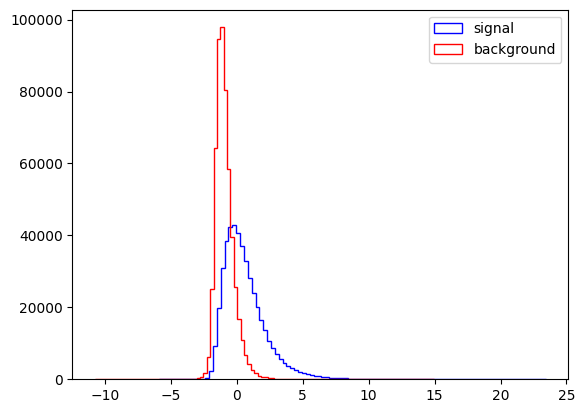

In [7]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

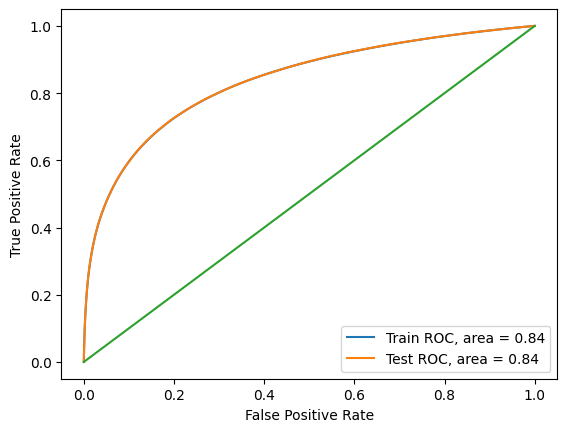

In [8]:
# ROC for training sample
from sklearn.metrics import roc_curve, auc

fpr_train, tpr_train, _ = roc_curve(y_Train, Fisher.decision_function(X_Train))
auc_train = auc(fpr_train, tpr_train)

# ROC for testing sample
fpr_test, tpr_test, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))
auc_test = auc(fpr_test, tpr_test)

# Plot both on one figure
plt.figure()
plt.plot(fpr_train, tpr_train, label="Train ROC, area = %0.2f" % auc_train)
plt.plot(fpr_test, tpr_test, label="Test ROC, area = %0.2f" % auc_test)
plt.plot([0,1],[0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

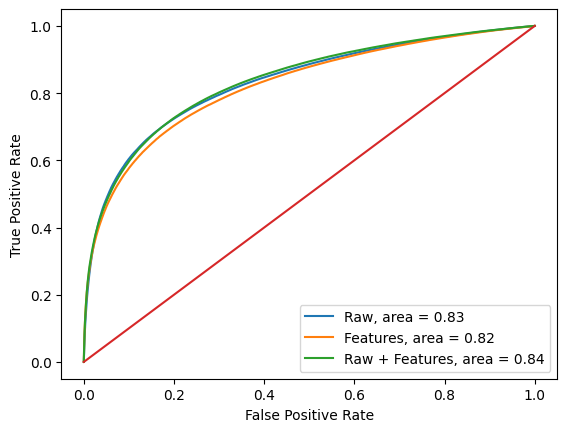

In [10]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

# Raw only
X_Train_raw = Train_Sample[RawNames]
X_Test_raw = Test_Sample[RawNames]

Fisher_raw = DA.LinearDiscriminantAnalysis()
Fisher_raw.fit(X_Train_raw, y_Train)

fpr_raw, tpr_raw, _ = roc_curve(y_Test, Fisher_raw.decision_function(X_Test_raw))
auc_raw = auc(fpr_raw, tpr_raw)

# Features only
X_Train_feat = Train_Sample[FeatureNames]
X_Test_feat = Test_Sample[FeatureNames]

Fisher_feat = DA.LinearDiscriminantAnalysis()
Fisher_feat.fit(X_Train_feat, y_Train)

fpr_feat, tpr_feat, _ = roc_curve(y_Test, Fisher_feat.decision_function(X_Test_feat))
auc_feat = auc(fpr_feat, tpr_feat)

# Raw + Features
X_Train_all = Train_Sample[VarNames[1:]]
X_Test_all = Test_Sample[VarNames[1:]]

Fisher_all = DA.LinearDiscriminantAnalysis()
Fisher_all.fit(X_Train_all, y_Train)

fpr_all, tpr_all, _ = roc_curve(y_Test, Fisher_all.decision_function(X_Test_all))
auc_all = auc(fpr_all, tpr_all)

# Plot all ROC curves
plt.figure()
plt.plot(fpr_raw, tpr_raw, label="Raw, area = %0.2f" % auc_raw)
plt.plot(fpr_feat, tpr_feat, label="Features, area = %0.2f" % auc_feat)
plt.plot(fpr_all, tpr_all, label="Raw + Features, area = %0.2f" % auc_all)
plt.plot([0,1],[0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

In [ ]:
import sklearn.discriminant_analysis as DA
from sklearn import svm
from sklearn.metrics import roc_curve, auc

# Make one function that does the same comparison for any classifier
def compare_classifier(clf, name):
    
    # Train the classifier
    clf.fit(X_Train, y_Train)
    
    # Get score on the testing sample
    score_test = clf.decision_function(X_Test)
    
    # Build ROC curve
    fpr, tpr, _ = roc_curve(y_Test, score_test)
    roc_auc = auc(fpr, tpr)
    
    # Plot ROC curve
    plt.plot(fpr, tpr, label=name + " area = %0.2f" % roc_auc)
    
    # Return what we need later
    return clf, fpr, tpr, roc_auc


plt.figure()

# Classifier 1: Fisher / LDA
Fisher = DA.LinearDiscriminantAnalysis()
Fisher_model, fpr_Fisher, tpr_Fisher, auc_Fisher = compare_classifier(Fisher, "Fisher")

# Classifier 2: QDA
QDA = DA.QuadraticDiscriminantAnalysis()
QDA_model, fpr_QDA, tpr_QDA, auc_QDA = compare_classifier(QDA, "QDA")

# Classifier 3: Support Vector Classifier
SVC = svm.SVC()
SVC_model, fpr_SVC, tpr_SVC, auc_SVC = compare_classifier(SVC, "SVC")

# Bad classifier reference line
plt.plot([0,1],[0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

In [11]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Get scores and predictions
scores = Fisher_all.decision_function(X_Test_all)
pred = Fisher_all.predict(X_Test_all)

# ROC and AUC
fpr, tpr, thresholds = roc_curve(y_Test, scores)
roc_auc = auc(fpr, tpr)

# TPR and FPR at default prediction threshold
TP = np.sum((y_Test == 1) & (pred == 1))
TN = np.sum((y_Test == 0) & (pred == 0))
FP = np.sum((y_Test == 0) & (pred == 1))
FN = np.sum((y_Test == 1) & (pred == 0))

TPR_value = TP / (TP + FN)
FPR_value = FP / (FP + TN)

# Other metrics
precision_value = precision_score(y_Test, pred)
recall_value = recall_score(y_Test, pred)
f1_value = f1_score(y_Test, pred)
accuracy_value = accuracy_score(y_Test, pred)

# Maximal significance
significance = tpr / np.sqrt(fpr + 1e-12)
max_significance = np.max(significance)

# Put results in a table
Metric = ["TPR", "FPR", "AUC", "Precision", "Recall", "F1 Score", "Accuracy", "Max Significance"]
Value = [TPR_value, FPR_value, roc_auc, precision_value, recall_value, f1_value, accuracy_value, max_significance]

Table = pd.DataFrame({
    "Metric": Metric,
    "Value": Value
})

print(Table)

             Metric       Value
0               TPR    0.576977
1               FPR    0.089865
2               AUC    0.836401
3         Precision    0.844491
4            Recall    0.576977
5          F1 Score    0.685562
6          Accuracy    0.757471
7  Max Significance  157.125305



#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 
